In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

plt.style.use("ggplot")

In [2]:
DATA_PATH = "../project/data/processed"

nav = pd.read_csv(
    f"{DATA_PATH}/02_nav_history_clean.csv"
)

fund = pd.read_csv(
    f"{DATA_PATH}/01_fund_master_clean.csv"
)

transactions = pd.read_csv(
    f"{DATA_PATH}/08_investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    f"{DATA_PATH}/09_portfolio_holdings_clean.csv"
)

performance = pd.read_csv(
    f"{DATA_PATH}/07_scheme_performance_clean.csv"
)

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

In [4]:
# Calculate daily returns

nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change()


risk_report = []

for fund_code in daily_returns.columns:
    
    returns = daily_returns[fund_code].dropna()
    
    var_95 = np.percentile(
        returns,
        5
    )
    
    cvar = returns[
        returns <= var_95
    ].mean()
    
    risk_report.append(
        {
            "amfi_code": fund_code,
            "VaR_95": var_95,
            "CVaR": cvar
        }
    )


risk_df = pd.DataFrame(
    risk_report
)

risk_df.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print(
    "VaR CVaR report saved"
)

VaR CVaR report saved


## Advanced Insight 1

Historical VaR analysis identified downside risk across all mutual fund schemes. Funds with higher negative VaR values indicate larger potential daily losses during adverse market conditions.

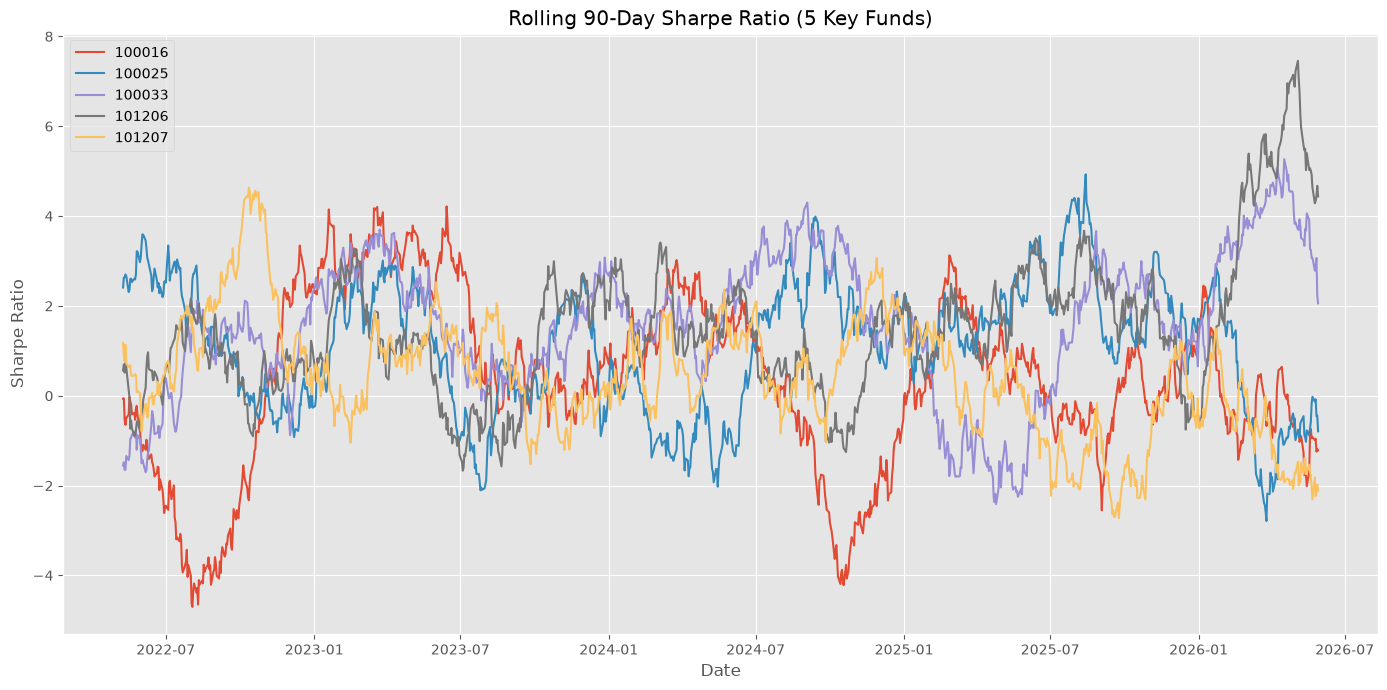

In [6]:
# Rolling 90-Day Sharpe Ratio

selected_funds = daily_returns.columns[:5]

rolling_sharpe = (
    daily_returns[selected_funds]
    .rolling(90)
    .mean()
    /
    daily_returns[selected_funds]
    .rolling(90)
    .std()
) * np.sqrt(252)


plt.figure(figsize=(14,7))

for fund_code in selected_funds:
    
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[fund_code],
        label=fund_code
    )


plt.title(
    "Rolling 90-Day Sharpe Ratio (5 Key Funds)"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.show()

In [7]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

print("Rolling Sharpe chart saved")

Rolling Sharpe chart saved


<Figure size 640x480 with 0 Axes>

## Advanced Insight 2

Rolling 90-day Sharpe Ratio analysis shows risk-adjusted performance trends of selected funds. Higher Sharpe values indicate better returns generated per unit of volatility.

In [8]:
# Investor Cohort Analysis

# First transaction year for each investor

first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)


# Add cohort year back to transactions

transactions_cohort = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id"
)


# Average SIP Amount and Total Invested

cohort_summary = (
    transactions_cohort
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)


cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [9]:
top_funds = (
    transactions_cohort
    .groupby(
        [
            "cohort_year",
            "amfi_code"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)


top_preference = (
    top_funds
    .sort_values(
        [
            "cohort_year",
            "count"
        ],
        ascending=False
    )
    .groupby(
        "cohort_year"
    )
    .head(1)
)


top_preference

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


## Advanced Insight 3

Investor cohort analysis shows yearly investor behaviour patterns, including average SIP contribution, total investment value, and preferred mutual fund schemes for each cohort.

In [10]:
# SIP Continuity Analysis

sip_data = transactions[
    transactions["transaction_type"] == "Sip"
]


# investors with 6+ SIP transactions

sip_count = (
    sip_data
    .groupby("investor_id")
    .size()
)

active_investors = sip_count[
    sip_count >= 6
].index


sip_active = sip_data[
    sip_data["investor_id"].isin(active_investors)
]


# sort transactions

sip_active = sip_active.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)


# calculate gap between SIP dates

sip_active["gap_days"] = (
    sip_active
    .groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)


# average gap

sip_gap = (
    sip_active
    .groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)


# flag at-risk

sip_gap["status"] = np.where(
    sip_gap["gap_days"] > 35,
    "At Risk",
    "Regular"
)


sip_gap.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [11]:
sip_gap["status"].value_counts()

status
At Risk    1332
Regular      30
Name: count, dtype: int64

## Advanced Insight 4

SIP continuity analysis identified investors with irregular investment behaviour. Investors having an average SIP gap greater than 35 days were flagged as at-risk for possible discontinuation.